Linear & Polynomial Regression Demo



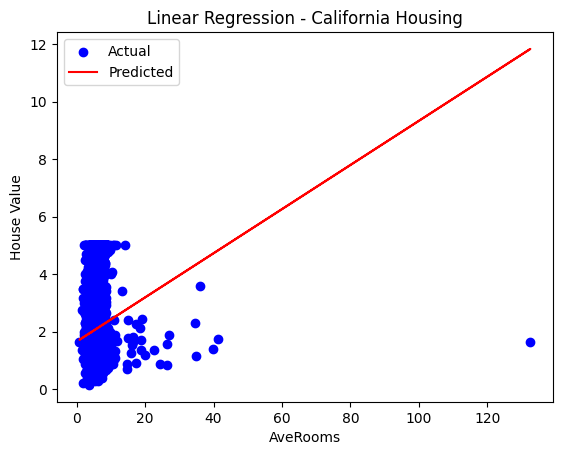


Linear Regression
MSE: 1.2923314440807299
R2: 0.013795337532284901


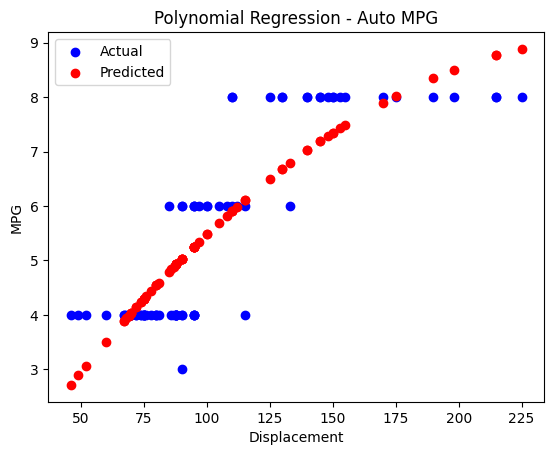


Polynomial Regression
MSE: 0.743149055720586
R2: 0.7505650609469627


In [5]:
#lab7
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

def linear_reg():
    X = fetch_california_housing(as_frame=True).data[["AveRooms"]]
    y = fetch_california_housing(as_frame=True).target
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression().fit(Xtr, ytr)
    yp = model.predict(Xte)

    plt.scatter(Xte, yte, c="blue", label="Actual")
    plt.plot(Xte, yp, c="red", label="Predicted")
    plt.xlabel("AveRooms"); plt.ylabel("House Value")
    plt.title("Linear Regression - California Housing")
    plt.legend(); plt.show()

    print("\nLinear Regression")
    print("MSE:", mean_squared_error(yte, yp))
    print("R2:", r2_score(yte, yp))

def poly_reg():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
    cols = ["mpg","cylinders","displacement","horsepower","weight","acceleration","model_year","origin"]
    data = pd.read_csv(url, sep=r"\s+", names=cols, na_values="?").dropna()

    X, y = data[["displacement"]], data["mpg"]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

    model = make_pipeline(PolynomialFeatures(2), StandardScaler(), LinearRegression())
    model.fit(Xtr, ytr)
    yp = model.predict(Xte)

    plt.scatter(Xte, yte, c="blue", label="Actual")
    plt.scatter(Xte, yp, c="red", label="Predicted")
    plt.xlabel("Displacement"); plt.ylabel("MPG")
    plt.title("Polynomial Regression - Auto MPG")
    plt.legend(); plt.show()

    print("\nPolynomial Regression")
    print("MSE:", mean_squared_error(yte, yp))
    print("R2:", r2_score(yte, yp))

if __name__ == "__main__":
    print("Linear & Polynomial Regression Demo\n")
    linear_reg()
    poly_reg()